In [43]:
# Cross-Country Analysis of YouTube Video Engagement

# This project analyzes YouTube trending videos from the USA, India, and Canada to identify the factors that influence video engagement. 
# The study focuses on key attributes such as video category, title characteristics, and engagement rate to uncover patterns in audience interaction
# across different countries. The findings are presented using Python for data cleaning and statistical testing and Power BI for interactive visualization
# and dashboarding.

# Name: Mohamad Zain


In [44]:
# Dataset Overview

# The dataset used in this project consists of YouTube trending videos collected from the USA, India, and Canada. It includes metadata such as video 
# title, channel name, category, publish date, views, likes, comments, and country of origin. Additional features, including engagement rate and title 
# length, were engineered during preprocessing to support deeper analysis.

# The primary objective of this project is to examine how video category and title characteristics influence engagement and to compare these patterns 
# across different countries using descriptive visualizations and inferential statistical analysis.

In [45]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns

In [46]:
# 1) Load YouTube trending datasets from USA, India, and Canada

us = pd.read_csv("USvideos.csv")
ind = pd.read_csv("INvideos.csv")
ca = pd.read_csv("CAvideos.csv")

print(us.shape, ind.shape, ca.shape)


(40949, 16) (37352, 16) (40881, 16)


In [47]:
# 2) Category Mapping Verfication before integrating the datasets

# 2.1 Load category mapping JSON files for each country

with open("US_category_id.json", "r") as f:
    us_json = json.load(f)

with open("IN_category_id.json", "r") as f:
    in_json = json.load(f)

with open("CA_category_id.json", "r") as f:
    ca_json = json.load(f)

In [48]:
# 2.2 Convert JSON category information into Python dictionaries

us_categories = {
    int(item["id"]): item["snippet"]["title"]
    for item in us_json["items"]
}

india_categories = {
    int(item["id"]): item["snippet"]["title"]
    for item in in_json["items"]
}

canada_categories = {
    int(item["id"]): item["snippet"]["title"]
    for item in ca_json["items"]
}

In [49]:
# 2.3 Verify that category IDs represent the same categories across countries

print("USA Categories:")
print(us_categories)

print("\nIndia Categories:")
print(india_categories)

print("\nCanada Categories:")
print(canada_categories)

print("\nUSA == India :", us_categories == india_categories)
print("USA == Canada:", us_categories == canada_categories)
print("India == Canada:", india_categories == canada_categories)

usa_only = (
    set(us_categories.keys())
    - set(india_categories.keys())
    - set(canada_categories.keys())
)

india_only = (
    set(india_categories.keys())
    - set(us_categories.keys())
    - set(canada_categories.keys())
)

canada_only = (
    set(canada_categories.keys())
    - set(us_categories.keys())
    - set(india_categories.keys())
)

print("\nOnly in USA:", sorted(usa_only))
print("Only in India:", sorted(india_only))
print("Only in Canada:", sorted(canada_only))

all_unique = usa_only.union(india_only).union(canada_only)

for category_id in sorted(all_unique):

    print(f"\nCategory ID {category_id}:")

    print("  USA    ->", us_categories.get(category_id))
    print("  India  ->", india_categories.get(category_id))
    print("  Canada ->", canada_categories.get(category_id))

USA Categories:
{1: 'Film & Animation', 2: 'Autos & Vehicles', 10: 'Music', 15: 'Pets & Animals', 17: 'Sports', 18: 'Short Movies', 19: 'Travel & Events', 20: 'Gaming', 21: 'Videoblogging', 22: 'People & Blogs', 23: 'Comedy', 24: 'Entertainment', 25: 'News & Politics', 26: 'Howto & Style', 27: 'Education', 28: 'Science & Technology', 29: 'Nonprofits & Activism', 30: 'Movies', 31: 'Anime/Animation', 32: 'Action/Adventure', 33: 'Classics', 34: 'Comedy', 35: 'Documentary', 36: 'Drama', 37: 'Family', 38: 'Foreign', 39: 'Horror', 40: 'Sci-Fi/Fantasy', 41: 'Thriller', 42: 'Shorts', 43: 'Shows', 44: 'Trailers'}

India Categories:
{1: 'Film & Animation', 2: 'Autos & Vehicles', 10: 'Music', 15: 'Pets & Animals', 17: 'Sports', 18: 'Short Movies', 19: 'Travel & Events', 20: 'Gaming', 21: 'Videoblogging', 22: 'People & Blogs', 23: 'Comedy', 24: 'Entertainment', 25: 'News & Politics', 26: 'Howto & Style', 27: 'Education', 28: 'Science & Technology', 30: 'Movies', 31: 'Anime/Animation', 32: 'Action/

In [50]:
## Findings

# - Category mappings are consistent across USA, India, and Canada.
# - No category ID corresponds to different category names across countries.
# - The only exception is Category ID 29 (Nonprofits & Activism), which appears only in the USA dataset.
# - Therefore, a common category mapping can be safely used when combining the datasets.


In [51]:
# 3) Add readable category names and country labels to each dataset

common_categories = us_categories
# USA had the most complete category mapping and was used as the common reference dictionary.

us["category"] = us["category_id"].map(common_categories)
ind["category"] = ind["category_id"].map(common_categories)
ca["category"] = ca["category_id"].map(common_categories)

us["country"] = "USA"
ind["country"] = "India"
ca["country"] = "Canada"

In [52]:
# 4) Combine datasets from all countries into a single dataframe

df = pd.concat(
    [us, ind, ca],
    ignore_index=True
)

print("Combined Dataset Shape:")
print(df.shape)

print("\nCountries Included:")
print(df["country"].value_counts())


Combined Dataset Shape:
(119182, 18)

Countries Included:
country
USA       40949
Canada    40881
India     37352
Name: count, dtype: int64


In [53]:
# 5) Data Cleaning

# 5.1 Check for missing values

print(df.isnull().sum())

# 5.2 Remove duplicate records

df = df.drop_duplicates(subset=["video_id", "country"], keep="last")

print("\nDataset Shape After Removing Duplicates:")
print(df.shape)

# 5.3 Remove records with zero views

df = df[df["views"] > 0]

print("\nDataset Shape After Removing Zero Views:")
print(df.shape)

# 5.4 Deleting corrupted video_ids
df = df[~df["video_id"].isin(["#NAME?", "#VALUE!"])]
df = df.reset_index(drop=True)
df.to_csv("youtube_video_engagement_combined_cleaned.csv", index=False)

video_id                     0
trending_date                0
title                        0
channel_title                0
category_id                  0
publish_time                 0
tags                         0
views                        0
likes                        0
dislikes                     0
comment_count                0
thumbnail_link               0
comments_disabled            0
ratings_disabled             0
video_error_or_removed       0
description               2427
category                     0
country                      0
dtype: int64

Dataset Shape After Removing Duplicates:
(47085, 18)

Dataset Shape After Removing Zero Views:
(47085, 18)


In [54]:
# 6. Feature Engineering

# 6.1 Convert publish time to datetime format
df["publish_time"] = pd.to_datetime(df["publish_time"])

# 6.2 Create engagement rate
df["engagement_rate (%)"] = (
    (df["likes"] + df["comment_count"]) / df["views"] 
)*100

# 6.3 Extract publishing hour
df["publish_hour"] = df["publish_time"].dt.hour

# 6.4 Extract publishing day of week
df["publish_day"] = df["publish_time"].dt.day_name()

# 6.5 Categorize publishing time into time periods

def get_time_period(hour):

    if 5 <= hour < 12:
        return "Morning"

    elif 12 <= hour < 17:
        return "Afternoon"

    elif 17 <= hour < 21:
        return "Evening"

    else:
        return "Night"


df["time_period"] = (
    df["publish_hour"]
    .apply(get_time_period)
)

# 6.6 Calculate title length in words
df["title_length_words"] = (
    df["title"]
    .fillna("")
    .str.split()
    .str.len()
)

# Verify engineered features

print(
    df[
        [
            "country",
            "category",
            "engagement_rate (%)",
            "publish_hour",
            "publish_day",
            "title_length_words"
        ]
    ].head()
)



  country              category  engagement_rate (%)  publish_hour  \
0     USA                Sports             1.022402             2   
1     USA      Film & Animation             3.331695            18   
2     USA       News & Politics             2.072732            21   
3     USA         Entertainment             1.117546            19   
4     USA  Science & Technology             0.908528            12   

  publish_day  title_length_words  
0      Monday                  16  
1      Sunday                   8  
2      Sunday                  10  
3      Friday                  13  
4      Friday                   9  


In [55]:
# 7) Dataset verification
#Review dataset structure
print(df.info())

# Display first few records
df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47083 entries, 0 to 47082
Data columns (total 23 columns):
 #   Column                  Non-Null Count  Dtype              
---  ------                  --------------  -----              
 0   video_id                47083 non-null  object             
 1   trending_date           47083 non-null  object             
 2   title                   47083 non-null  object             
 3   channel_title           47083 non-null  object             
 4   category_id             47083 non-null  int64              
 5   publish_time            47083 non-null  datetime64[ns, UTC]
 6   tags                    47083 non-null  object             
 7   views                   47083 non-null  int64              
 8   likes                   47083 non-null  int64              
 9   dislikes                47083 non-null  int64              
 10  comment_count           47083 non-null  int64              
 11  thumbnail_link          47083 non-null  o

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,...,ratings_disabled,video_error_or_removed,description,category,country,engagement_rate (%),publish_hour,publish_day,time_period,title_length_words
0,9wRQljFNDW8,17.14.11,Dion Lewis' 103-Yd Kick Return TD vs. Denver! ...,NFL,17,2017-11-13 02:05:26+00:00,"NFL|""Football""|""offense""|""defense""|""afc""|""nfc""...",81377,655,25,...,False,False,New England Patriots returner Dion Lewis blast...,Sports,USA,1.022402,2,Monday,Night,16
1,Om_zGhJLZ5U,17.14.11,TL;DW - Every DCEU Movie Before Justice League,Screen Junkies,1,2017-11-12 18:00:03+00:00,"screenjunkies|""screen junkies""|""sj news""|""hone...",288922,7515,792,...,False,False,With Justice League approaching fast we rewatc...,Film & Animation,USA,3.331695,18,Sunday,Evening,8
2,goP4Z5wyOlM,17.14.11,Iraq-Iran earthquake: Deadly tremor hits borde...,BBC News,25,2017-11-12 21:16:40+00:00,"bbc|""bbc news""|""news""|""iran""|""iran news""|""iraq...",34785,308,26,...,False,False,A strong 7.2-magnitude earthquake has rattled ...,News & Politics,USA,2.072732,21,Sunday,Night,10
3,8NHA23f7LvU,17.14.11,Jason Momoa Wows Hugh Grant With Some Dothraki...,The Graham Norton Show,24,2017-11-10 19:06:23+00:00,"Graham Norton|""Graham Norton Show Official""|""E...",1496225,16116,236,...,False,False,I think Sarah Millican was very excited for th...,Entertainment,USA,1.117546,19,Friday,Evening,13
4,IE-xepGLVt8,17.14.11,Mayo Clinic's first face transplant patient me...,Mayo Clinic,28,2017-11-10 12:04:17+00:00,"Mayo Clinic|""Health Care (Issue)""|""Healthcare ...",237307,1896,74,...,False,False,One and a half years after the surgery that tr...,Science & Technology,USA,0.908528,12,Friday,Afternoon,9


In [56]:
# 8) Save cleaned dataset for statistical analysis and Power BI

df=df.reset_index(drop=True)
df.to_csv("youtube_video_engagement_combined_cleaned.csv", index=False) 

print("Dataset exported successfully.")

Dataset exported successfully.


In [57]:
df.head()

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,...,ratings_disabled,video_error_or_removed,description,category,country,engagement_rate (%),publish_hour,publish_day,time_period,title_length_words
0,9wRQljFNDW8,17.14.11,Dion Lewis' 103-Yd Kick Return TD vs. Denver! ...,NFL,17,2017-11-13 02:05:26+00:00,"NFL|""Football""|""offense""|""defense""|""afc""|""nfc""...",81377,655,25,...,False,False,New England Patriots returner Dion Lewis blast...,Sports,USA,1.022402,2,Monday,Night,16
1,Om_zGhJLZ5U,17.14.11,TL;DW - Every DCEU Movie Before Justice League,Screen Junkies,1,2017-11-12 18:00:03+00:00,"screenjunkies|""screen junkies""|""sj news""|""hone...",288922,7515,792,...,False,False,With Justice League approaching fast we rewatc...,Film & Animation,USA,3.331695,18,Sunday,Evening,8
2,goP4Z5wyOlM,17.14.11,Iraq-Iran earthquake: Deadly tremor hits borde...,BBC News,25,2017-11-12 21:16:40+00:00,"bbc|""bbc news""|""news""|""iran""|""iran news""|""iraq...",34785,308,26,...,False,False,A strong 7.2-magnitude earthquake has rattled ...,News & Politics,USA,2.072732,21,Sunday,Night,10
3,8NHA23f7LvU,17.14.11,Jason Momoa Wows Hugh Grant With Some Dothraki...,The Graham Norton Show,24,2017-11-10 19:06:23+00:00,"Graham Norton|""Graham Norton Show Official""|""E...",1496225,16116,236,...,False,False,I think Sarah Millican was very excited for th...,Entertainment,USA,1.117546,19,Friday,Evening,13
4,IE-xepGLVt8,17.14.11,Mayo Clinic's first face transplant patient me...,Mayo Clinic,28,2017-11-10 12:04:17+00:00,"Mayo Clinic|""Health Care (Issue)""|""Healthcare ...",237307,1896,74,...,False,False,One and a half years after the surgery that tr...,Science & Technology,USA,0.908528,12,Friday,Afternoon,9


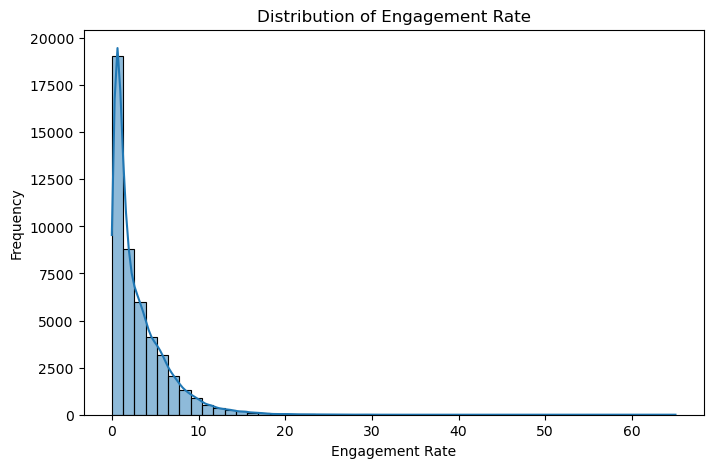

In [58]:
#EDA
# Histogram: Distribution of Engagement Rate
plt.figure(figsize=(8, 5))
sns.histplot(df["engagement_rate (%)"], bins=50, kde=True)
plt.title("Distribution of Engagement Rate")
plt.xlabel("Engagement Rate")
plt.ylabel("Frequency")
plt.show()

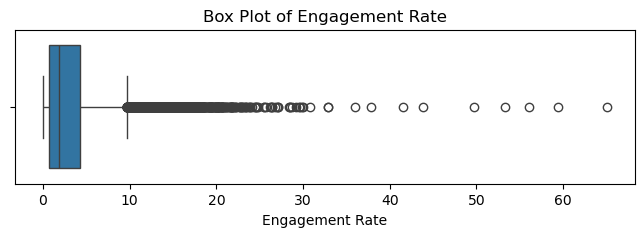

In [59]:
# Box Plot: Engagement Rate (to identify spread and outliers)
plt.figure(figsize=(8, 2))
sns.boxplot(x=df["engagement_rate (%)"])
plt.title("Box Plot of Engagement Rate")
plt.xlabel("Engagement Rate")
plt.show()

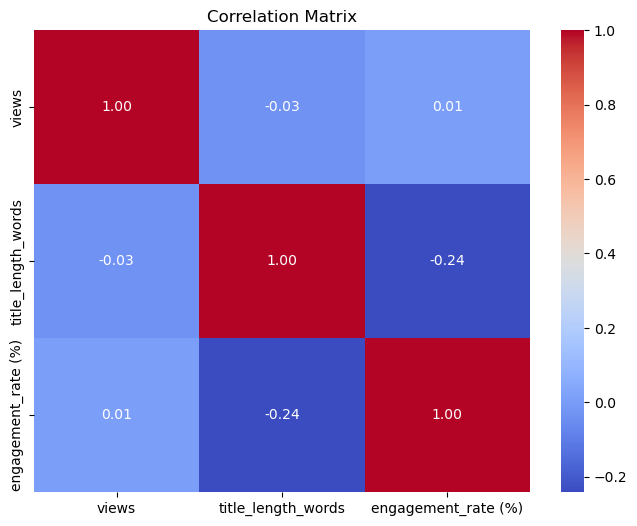

In [60]:
# Correlation Heatmap

numeric_cols = [
    "views",
    "title_length_words",
    "engagement_rate (%)"
] 

corr = df[numeric_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [61]:
#EDA findings 

# Key Observations
# The engagement rate distribution is right-skewed, with most videos having engagement rates below 5%.
# Several high-engagement outliers are present, likely representing viral videos rather than data errors.
# The correlation between title length and engagement rate is weakly negative (-0.24), suggesting that shorter titles tend to receive slightly higher engagement.


In [62]:
#Inferenial Analysis 

In [63]:
# Inferential Analysis

# To further investigate the factors influencing YouTube video engagement, inferential statistical tests were conducted.

# The following analyses were performed:

# 1. One-Way ANOVA to determine whether engagement rates differ significantly across video categories.
# 2. One-Way ANOVA to determine whether engagement rates differ significantly across countries.
# 3. Linear Regression to examine the relationship between title length and engagement rate.

# A significance level of α = 0.05 was used for all statistical tests.

In [64]:
## 1) One-Way ANOVA: Video Category vs Engagement Rate

# This test examines whether the average engagement rate differs significantly across YouTube video categories.

### Hypotheses

# H₀: The mean engagement rate is the same across all video categories.

# H₁: At least one video category has a different mean engagement rate.

In [65]:
## 1) One-Way ANOVA: Video Category vs Engagement Rate
# Import ANOVA function
from scipy.stats import f_oneway

# Create engagement groups for each category
groups = [
    group["engagement_rate (%)"].dropna().values
    for _, group in df.groupby("category")
]

# Perform One-Way ANOVA
f_stat, p_value = f_oneway(*groups)

print("=== ANOVA: Category vs Engagement ===")
print("F-statistic:", f_stat)
print(f"p-value: {p_value:.20e}")

if p_value < 0.05:
    print("Conclusion: There is a statistically significant difference in engagement across categories.")
else:
    print("Conclusion: No statistically significant difference was found across categories.")



=== ANOVA: Category vs Engagement ===
F-statistic: 482.5038408274462
p-value: 0.00000000000000000000e+00
Conclusion: There is a statistically significant difference in engagement across categories.


In [66]:
## 2) One-Way ANOVA: Country vs Engagement Rate

# This test examines whether average engagement rates differ significantly among the USA, India, and Canada.

### Hypotheses

# H₀: The mean engagement rate is the same across all countries.

# H₁: At least one country has a different mean engagement rate.

In [67]:
## 2) One-Way ANOVA: Country vs Engagement Rate

# Import ANOVA function
from scipy.stats import f_oneway

# Create engagement groups for each country
groups = [
    group["engagement_rate (%)"].dropna().values
    for _, group in df.groupby("country")
]

# Perform One-Way ANOVA
f_stat, p_value = f_oneway(*groups)

print("=== ANOVA: Country vs Engagement ===")
print("F-statistic:", f_stat)
print("p-value:", format(p_value, ".20e"))

if p_value < 0.05:
    print("Conclusion: There is a statistically significant difference in engagement across countries.")
else:
    print("Conclusion: No statistically significant difference was found across countries.")

=== ANOVA: Country vs Engagement ===
F-statistic: 1154.847365569104
p-value: 0.00000000000000000000e+00
Conclusion: There is a statistically significant difference in engagement across countries.


In [68]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# 3) Tukey HSD: Country vs Engagement Rate (%)

tukey_country = pairwise_tukeyhsd(
    endog=df["engagement_rate (%)"],
    groups=df["country"],
    alpha=0.05
)

print(tukey_country)

from statsmodels.stats.multicomp import pairwise_tukeyhsd


Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower   upper  reject
---------------------------------------------------
Canada  India  -1.5124   0.0 -1.5876 -1.4371   True
Canada    USA  -0.1989   0.0 -0.3037 -0.0941   True
 India    USA   1.3135   0.0  1.2034  1.4235   True
---------------------------------------------------


In [69]:
#Key findings

In [70]:
# Key Findings
# One-way ANOVA revealed that average engagement rates differ significantly across video categories, indicating that content category influences audience engagement.

# Significant differences in engagement were also observed across countries. Tukey's HSD post hoc test confirmed that Canada, the USA, and India each have statistically different average engagement rates.

# Title length exhibited a weak negative relationship with engagement rate, suggesting that shorter titles tend to receive slightly higher engagement.

# Exploratory Data Analysis (EDA) showed that engagement rates are right-skewed, with a small number of highly engaging videos acting as outliers.

# Recommendations for content creators
# Use concise and informative video titles to potentially improve audience engagement.

# Consider category-specific content strategies, as engagement varies significantly across different video categories.

# Adapt content for regional audiences, since engagement patterns differ across the USA, India, and Canada.

# Evaluate video performance using engagement rate rather than raw likes or comments, as it provides a normalized and more comparable measure across videos.

# Post hoc analysis using Tukey's HSD showed that all pairwise country comparisons were statistically significant (p < 0.05). Canada had the highest average engagement rate, followed by the USA, while India had the lowest